# SupraLocal Interpretable Model Agnostic Explanations (SLIME)

In this demo we explain the SLIME algorithm and show you how to:
* Set up a `SLIMEModel` instance
* Approximate local behavior of a black-box model with `SLIMEModel.fit`
* Make predictions with the surrogate symbolic model with `SLIMEModel.predict`

SLIME is a very similar model interpretability technique to [LIME](https://arxiv.org/pdf/1602.04938) (Local Interpretable Model Agnostic Explanations). Essentially, LIME is a technique that approximates any black box machine learning model with a linear model around a certain point. The surrogate model is fitted with Gaussian perturbed samples around the point. 

SLIME extends this idea. Here, we implement the framework as presented by the [SLIME paper](https://dl.acm.org/doi/10.1145/3712255.3726721) (Fong, Motani 2025). 

![SLIME_conceptual_pic](../_static/SLIME.png)

**SLIME Algorithm**: Suppose we have a black-box model $f(x)$,
1. We want to fit a local surrogate model $g^{*}(x) \in \mathcal{G}$ where $\mathcal{S}$ is the space of closed-form analytic expressions (symbolic models) to estimate the behaviour of $f(x)$ around point $x_0$.
2. To choose our surrogate model, we create a dataset points near $x_0$. This dataset, $\mathcal{D}$, consists of the $J-$ nearest neighbours around $x_0$ and $N_{\text{synthetic}}$ number of Gaussian sampled points around $x_0$ (the default variance of the Gaussian is equal to half the variance of the set of $J$ neighbours, hence we choose the size of the neighbourhood by setting $J$).
3. We evaluate the outputs of the model on this dataset, $\mathcal{D}$, to create the targets for our symbolic regression $\mathcal{T}$.
4. We choose $g^{*}(x)$ by

$$
g^*(x) = \arg\min_{g \in \mathcal{S}} \sum_{z_i \in \text{synthetic}} \pi_x(z_i) [f(z_i)-g(z_i)]^2 + M \sum_{z_j \in \text{neighbours}} [f(z_j)-g(z_j)]^2
$$

where $\pi_x(z_i) = \exp(\frac{-||x_0-x_i||^2}{\sigma^2})$ is the proximity kernel weighting and $M$ is a weighting for the real neighbours.

SLIME has benefits over LIME as it does not restrict itself to linear models, yet does not have any reduction in interpretability of the surrogate model.

We present `symtorch.SLIMEModel`, which can fit a SLIME model for you. The user can specify:
* $J-$ nearest neighbours (`J_neighbours = 10`)
* $M$ (`real_weighting = 1.0`)
* $N_{\text{synthetic}}$ (`num_synthetic = 0`)

As well as

* Nearest neighbour metric (`nn_metric = "euclidean"`)
* PySR parameters (`pysr_params=None` defaults to default parameters)

The model is fitted using the `.fit()` method and predictions can be made using `.predict()`.

## Conceptual example

Let us see an example of how SLIME can be effective at analysing black box models by using a spiral dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

N = 400
theta = np.sqrt(np.random.rand(N)) * 2 * np.pi

# Class A spiral
r_a = 2 * theta + np.pi
data_a = np.column_stack([np.cos(theta) * r_a, np.sin(theta) * r_a])
x_a = data_a + np.random.randn(N, 2)
y_a = np.zeros(N, dtype=int)

# Class B spiral
r_b = -2 * theta - np.pi
data_b = np.column_stack([np.cos(theta) * r_b, np.sin(theta) * r_b])
x_b = data_b + np.random.randn(N, 2)
y_b = np.ones(N, dtype=int)

# Combine
X = np.vstack([x_a, x_b])
y = np.concatenate([y_a, y_b])

# Shuffle together
idx = np.random.permutation(len(y))
X = X[idx]
y = y[idx]

### The dataset

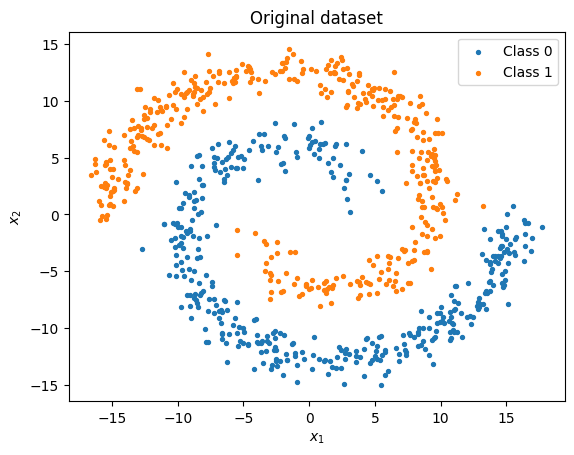

In [46]:
plt.scatter(X[y==0, 0], X[y==0, 1], s=8, label="Class 0")
plt.scatter(X[y==1, 0], X[y==1, 1], s=8, label="Class 1")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
plt.title('Original dataset')
plt.show()

### Training the model

Set up a simple two layer MLP.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleMLP(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=64, out_dim=2):
        super().__init__()
        self.layer1 = nn.Linear(in_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.output(x)      
        return x

In [4]:
from torch.utils.data import TensorDataset, DataLoader

X_tensor = torch.from_numpy(X).float()     
y_tensor = torch.from_numpy(y).long()         

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

Set up training.

In [5]:
device = torch.device("mps")

model = SimpleMLP(in_dim=2, hidden_dim=64, out_dim=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Train the model.

In [6]:
for epoch in range(50):
    model.train()
    running_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(dataset)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}, loss = {epoch_loss:.4f}")


Epoch 10, loss = 0.3328
Epoch 20, loss = 0.1364
Epoch 30, loss = 0.0511
Epoch 40, loss = 0.0275
Epoch 50, loss = 0.0181


Get predictions for the data.

In [7]:
def model_func(inputs):
    model.eval()
    with torch.no_grad():
        # convert numpy arrays to torch tensors
        if isinstance(inputs, np.ndarray):
            inputs = torch.from_numpy(inputs).float()
        
        # ensure tensor + move to device
        inputs = inputs.to(device)

        logits = model(inputs)
        probs = torch.softmax(logits, dim=-1)
        preds = probs.argmax(dim=-1).cpu().numpy()

    return preds


In [8]:
preds = model_func(X_tensor.to(device))

In [9]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y, preds)
print(f"The model accuracy on this dataset is {acc}.")

The model accuracy on this dataset is 0.99875.


## Interpreting the model outputs with SLIME

Imagining that we don't know the true form of the data, we would want to understand how the model behaves. For complex models, it is easier to see how the model behaves around a local point of interest. 

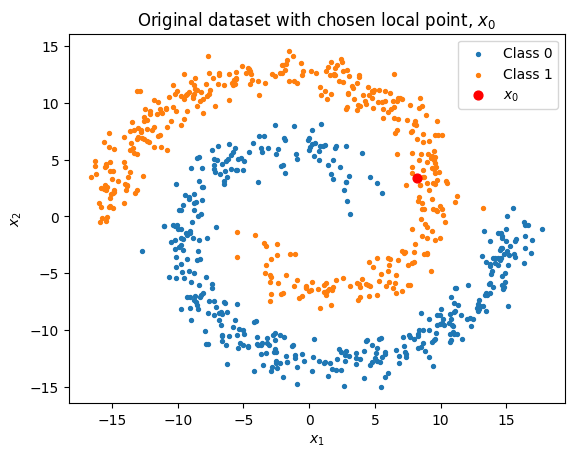

In [47]:
np.random.seed(7)
idx = np.random.randint(len(X))
x0 = X[idx]
plt.scatter(X[y==0, 0], X[y==0, 1], s=8, label="Class 0")
plt.scatter(X[y==1, 0], X[y==1, 1], s=8, label="Class 1")

# plot the special point on top
plt.scatter(x0[0], x0[1], color="red", s=40, label=r"$x_0$")

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Original dataset with chosen local point, $x_0$")
plt.legend()

Let us just restrict ourself to the neighbourhood of points close to $x_0$.

In [11]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=50, metric='euclidean').fit(X)
_, indices = nbrs.kneighbors(x0.reshape(1, -1))
neigh_idx = indices[0]

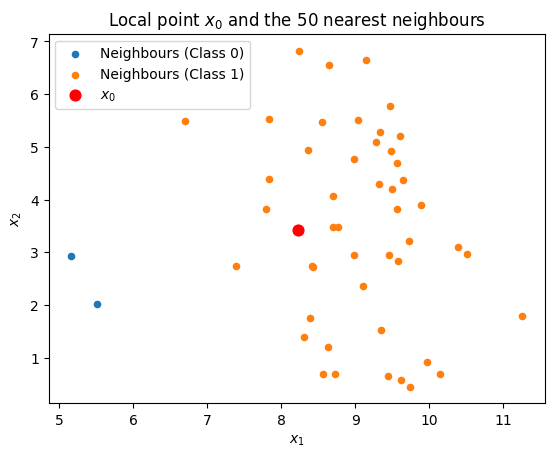

In [48]:
# plot neighbours using the same class-specific colours
plt.scatter(X[neigh_idx][y[neigh_idx] == 0, 0],
            X[neigh_idx][y[neigh_idx] == 0, 1],
            s=20, label="Neighbours (Class 0)")

plt.scatter(X[neigh_idx][y[neigh_idx] == 1, 0],
            X[neigh_idx][y[neigh_idx] == 1, 1],
            s=20, label="Neighbours (Class 1)")

# highlight x0
plt.scatter(x0[0], x0[1],
            s=60, color="red", label=r"$x_0$")

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
plt.title(r"Local point $x_0$ and the 50 nearest neighbours")
plt.show()


We can now add synthetic points to further explore the model classifications. We sample our synthetic points from the region around $x_0$ with the half the variance as the $J-$ nearest neighbours.

In [13]:
var = np.var(X[neigh_idx])
synthetic_samples = np.random.normal(loc=x0, scale=np.sqrt(var)/2, size=(10_000, len(x0)))

Put our synthetic samples and our real samples into the model to see how they are classified.

In [14]:
real_inputs = X[neigh_idx]

real_preds = model_func(torch.from_numpy(real_inputs).float().to(device))
synthetic_preds = model_func(torch.from_numpy(synthetic_samples).float().to(device))


In [15]:
real_preds.shape

(50,)

Text(0.5, 1.0, 'Real and synthetic points in neighbourhood of $x_0$')

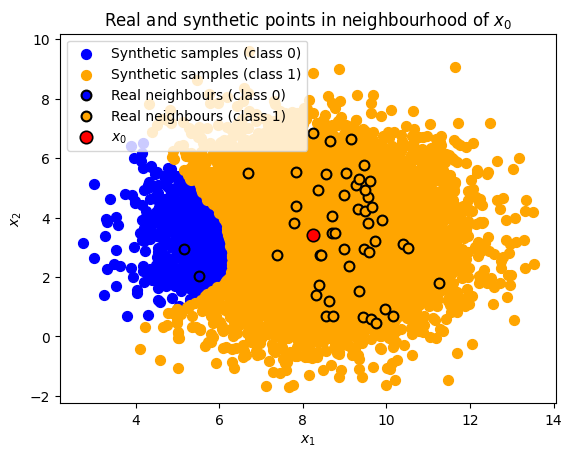

In [50]:
plt.scatter(synthetic_samples[synthetic_preds == 0, 0],
            synthetic_samples[synthetic_preds == 0, 1],
            s=50, facecolor="blue", label="Synthetic samples (class 0)")

plt.scatter(synthetic_samples[synthetic_preds == 1, 0],
            synthetic_samples[synthetic_preds == 1, 1],
            s=50, facecolor="orange", label="Synthetic samples (class 1)")

plt.scatter(real_inputs[real_preds == 0, 0],
            real_inputs[real_preds == 0, 1],
            s=50, facecolor="blue", edgecolor="black",
            linewidth=1.5, label="Real neighbours (class 0)"

)

# class 1 neighbours
plt.scatter(real_inputs[real_preds == 1, 0],
            real_inputs[real_preds == 1, 1],
            s=50, facecolor="orange", edgecolor="black",
            linewidth=1.5, label="Real neighbours (class 1)"
)


# 4 — highlight x0
plt.scatter(x0[0], x0[1],
            s=80, color="red", edgecolor="black", linewidth=1.2,
            label=r"$x_0$")


plt.legend()
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Real and synthetic points in neighbourhood of $x_0$")

This is how the model classfies the points in this neighbourhood. Now we can approximate the behaviour of this model using a symbolic expression.

In [17]:
from symtorch import SLIMEModel

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Set up the SLIME model.

In [ ]:
slime_model = SLIMEModel(
    J_neighbours=50,
    num_synthetic=10_000,  
    nn_metric='euclidean',
    pysr_params={
        'niterations': 500,
        'binary_operators': ['+', '*', '-', '/', 'cond'],
        'unary_operators': ['sin', 'cos', 'exp', 'log', 'sqrt'],
        'complexity_of_operators': {'sin': 3, 'cos': 3, 'exp': 3, 'log': 3, 'sqrt': 2, 'cond': 2}, 
        'constraints':{'exp': 2, 'log':2, 'sin':2, 'cos':2},
        'verbosity': 0
    }
)

In [23]:
slime_model.fit(model_func, X, x=x0, var = var)

Fitting SLIME with 10050 points (50 real + 10000 synthetic)


/Users/liz/PhD/SymTorch_project/symtorch_venv/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/liz/PhD/SymTorch_project/symtorch_venv/lib/python3.11/site-packages/pysr/sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(


This is the equation that the symbolic regression found:

In [24]:
slime_model.get_equation()

'cond(((x0 * 1.456952) + cos(x1)) + cond((0.99702936 / x1) + -0.15574795, -8.182976), 0.99560946)'

which is some sort of conditional decision boundary.

Now let's see if our SLIME model has approximated the local behaviour well...

In [27]:
slime_predictions=slime_model.predict(synthetic_samples)

In [33]:
slime_labels = (slime_predictions >= 0.5).astype(int)

Text(0.5, 1.0, 'SLIME surrogate model predictions of synthetic data in $x_0$ neighbourhood')

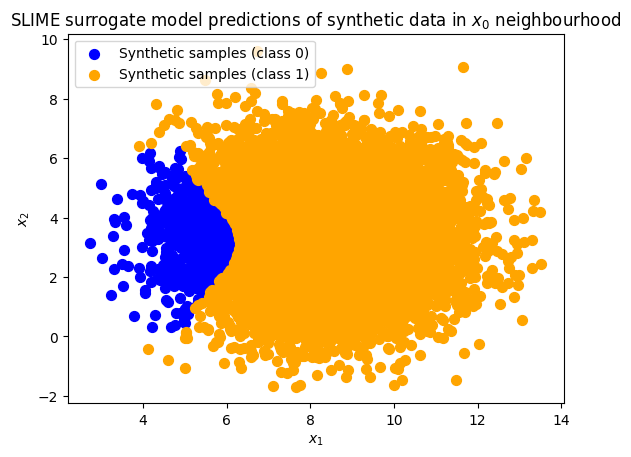

In [52]:
plt.scatter(
    synthetic_samples[slime_labels == 0, 0],
    synthetic_samples[slime_labels == 0, 1],
    s=50, facecolor="blue", label="Synthetic samples (class 0)"
)

plt.scatter(
    synthetic_samples[slime_labels == 1, 0],
    synthetic_samples[slime_labels == 1, 1],
    s=50, facecolor="orange", label="Synthetic samples (class 1)"
)

plt.legend()
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"SLIME surrogate model predictions of synthetic data in $x_0$ neighbourhood")

It has done a pretty good job!

Let's visualise the SLIME decision boundary on the true dataset.

Text(0.5, 1.0, 'Decision Boundary of Local Symbolic Surrogate Model')

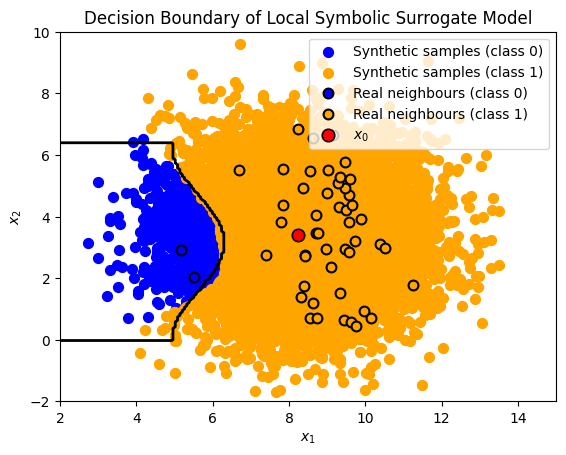

In [57]:
# make a grid covering data
x0_min, x0_max = X[:,0].min() - 1, X[:,0].max() + 1
x1_min, x1_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 600),
    np.linspace(x1_min, x1_max, 600)
)

# evaluate model
grid = np.column_stack([xx.ravel(), yy.ravel()])   # shape (600*600, 2)
Z = slime_model.predict(grid)

Z = np.asarray(Z).reshape(-1)   # ensure 1D
Z = Z.reshape(xx.shape) 

# plot ONLY the boundary line
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

#plot the original data
plt.scatter(synthetic_samples[synthetic_preds == 0, 0],
            synthetic_samples[synthetic_preds == 0, 1],
            s=50, facecolor="blue", label="Synthetic samples (class 0)")

plt.scatter(synthetic_samples[synthetic_preds == 1, 0],
            synthetic_samples[synthetic_preds == 1, 1],
            s=50, facecolor="orange", label="Synthetic samples (class 1)")

plt.scatter(real_inputs[real_preds == 0, 0],
            real_inputs[real_preds == 0, 1],
            s=50, facecolor="blue", edgecolor="black",
            linewidth=1.5, label="Real neighbours (class 0)")
plt.scatter(real_inputs[real_preds == 1, 0],
            real_inputs[real_preds == 1, 1],
            s=50, facecolor="orange", edgecolor="black",
            linewidth=1.5, label="Real neighbours (class 1)")
plt.scatter(x0[0], x0[1],
            s=80, color="red", edgecolor="black", linewidth=1.2,
            label=r"$x_0$")

plt.xlim(2,15)
plt.ylim(-2,10)

plt.legend()
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")

plt.title("Decision Boundary of Local Symbolic Surrogate Model")
